# Purchase Conversion Prediction — ML Classification
**Goal:** Build and evaluate binary classification models to predict purchase conversion

## 1. Setup & Data Preparation

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df = pd.read_csv('/content/drive/MyDrive/Kaggle/E-Commerce Data Set/ecommerce_user_behavior_8000.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (8000, 14)


,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0


## 2. Feature Engineering

In [5]:
df_model = df.copy()

# Encode categoricals
le = LabelEncoder()
df_model['gender_enc'] = le.fit_transform(df_model['gender'].fillna('Unknown'))
df_model['device_enc'] = le.fit_transform(df_model['device_type'].fillna('Unknown'))

df_model['engagement_score'] = (
    df_model['time_on_site'].fillna(0) *
    df_model['pages_viewed'].fillna(0)
)
df_model['cart_to_pages_ratio'] = (
    df_model['cart_items'].fillna(0) /
    (df_model['pages_viewed'].fillna(1) + 1)
)
df_model['high_intent'] = (
    (df_model['cart_items'] > df_model['cart_items'].median()) &
    (df_model['bounce_rate'] < df_model['bounce_rate'].median())
).astype(int)

feature_cols = [
    'age', 'gender_enc', 'device_enc', 'time_on_site', 'pages_viewed',
    'previous_purchases', 'cart_items', 'discount_seen', 'ad_clicked',
    'returning_user', 'avg_session_time', 'bounce_rate',
    'engagement_score', 'cart_to_pages_ratio', 'high_intent'
]

X = df_model[feature_cols]
y = df_model['purchase'].fillna(0).astype(int)

print(f'Features: {len(feature_cols)}')
print(f'Class balance — 0: {(y==0).sum():,} | 1: {(y==1).sum():,}')

Features: 15
Class balance — 0: 173 | 1: 7,827


## 3. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 6,400 | Test: 1,600


## 4. Model Training — Three Classifiers

In [7]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42))
    ])
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'avg_precision': average_precision_score(y_test, y_prob)
    }
    print(f"{name}: AUC={results[name]['roc_auc']:.4f} | CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Logistic Regression: AUC=0.5320 | CV AUC=0.5376 ± 0.0194
Random Forest: AUC=0.5562 | CV AUC=0.5218 ± 0.0739
Gradient Boosting: AUC=0.5180 | CV AUC=0.5144 ± 0.0307


## 5. Model Comparison

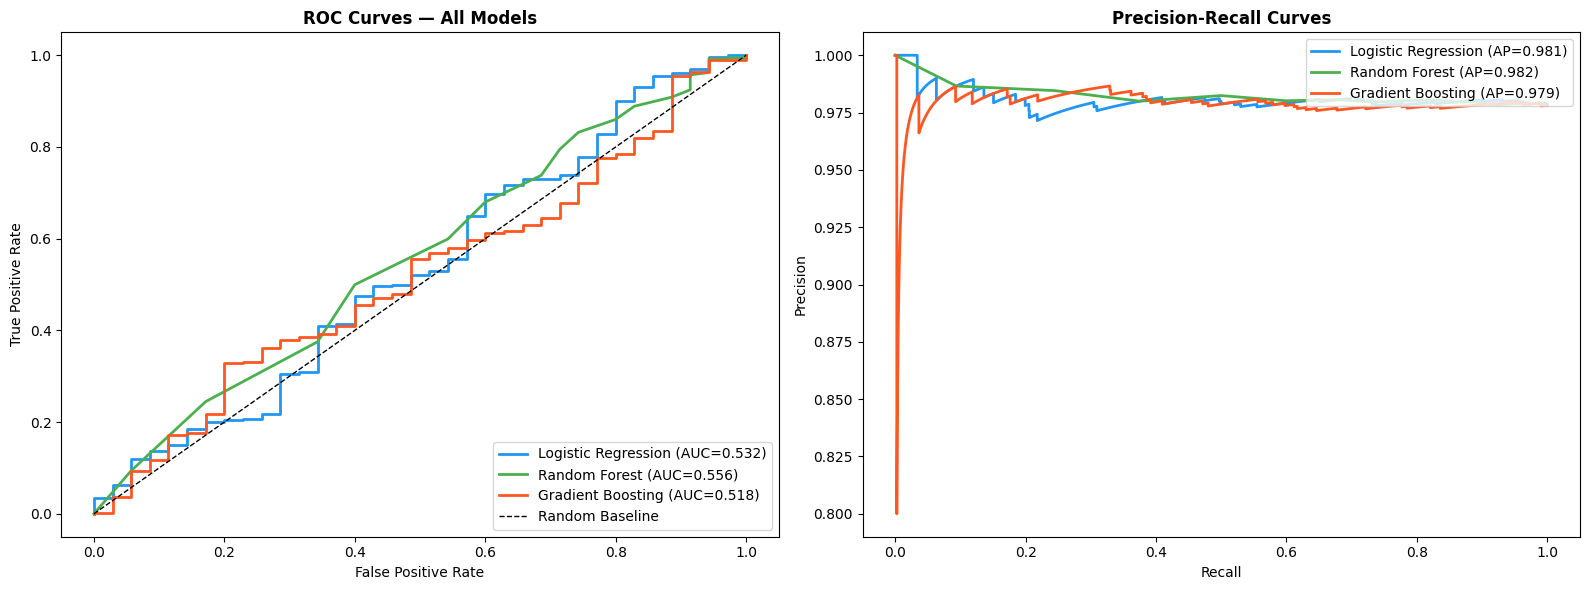

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
colors = ['#2196F3', '#4CAF50', '#FF5722']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={res['roc_auc']:.3f})")

axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Random Baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(loc='lower right')

# Precision-Recall Curves
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, lw=2, color=color,
                 label=f"{name} (AP={res['avg_precision']:.3f})")

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 6. Best Model — Detailed Evaluation

In [9]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = results[best_name]
print(f'Best Model: {best_name}')
print(f'Test AUC: {best["roc_auc"]:.4f}')
print(f'\n{classification_report(y_test, best["y_pred"], target_names=["No Purchase","Purchased"])}')

Best Model: Random Forest
Test AUC: 0.5562

              precision    recall  f1-score   support

 No Purchase       0.00      0.00      0.00        35
   Purchased       0.98      1.00      0.99      1565

    accuracy                           0.98      1600
   macro avg       0.49      0.50      0.49      1600
weighted avg       0.96      0.98      0.97      1600



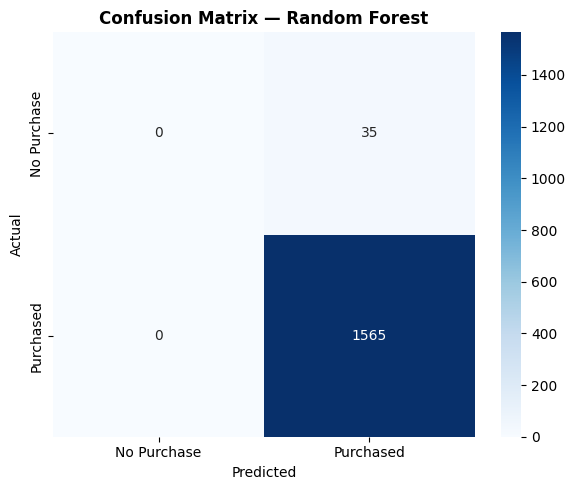

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Purchase', 'Purchased'],
            yticklabels=['No Purchase', 'Purchased'])
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

## 7. Feature Importance

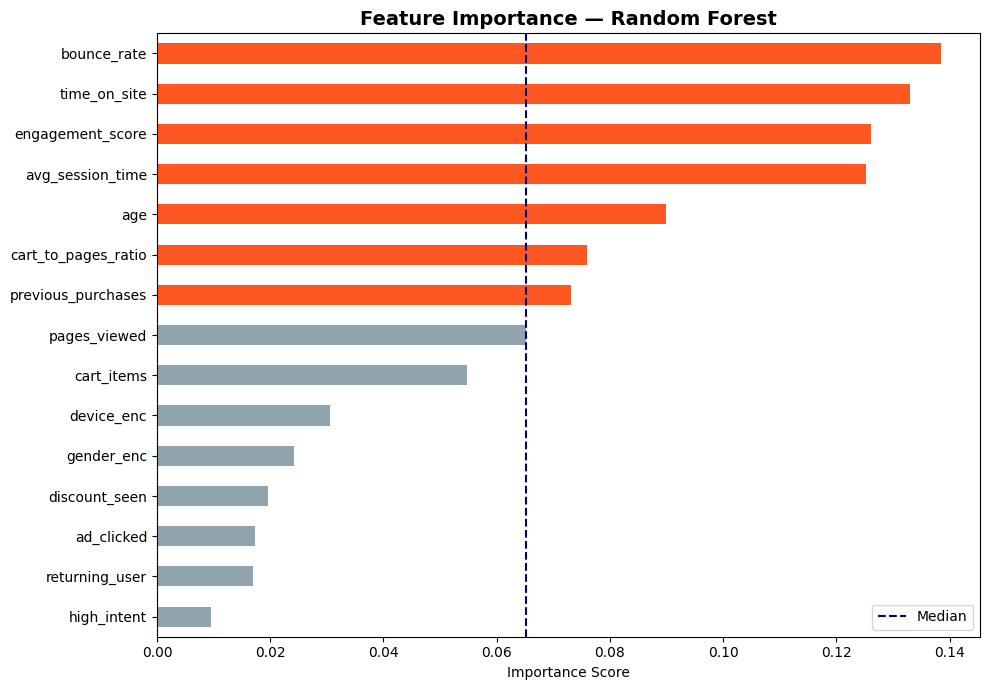

In [11]:
# Use Random Forest for feature importance
rf_pipe = results['Random Forest']['pipeline']
importances = rf_pipe.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#FF5722' if v > feat_imp.median() else '#90A4AE' for v in feat_imp]
feat_imp.plot(kind='barh', ax=ax, color=colors_imp)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(feat_imp.median(), color='navy', linestyle='--', lw=1.5, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Model Performance Summary

In [12]:
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test AUC': [r['roc_auc'] for r in results.values()],
    'CV AUC (mean)': [r['cv_auc_mean'] for r in results.values()],
    'CV AUC (std)': [r['cv_auc_std'] for r in results.values()],
    'Avg Precision': [r['avg_precision'] for r in results.values()]
}).round(4)

print(summary_df.to_string(index=False))
print(f'\nBest Model: {best_name} | AUC: {best["roc_auc"]:.4f}')
top_features = feat_imp.sort_values(ascending=False).head(3).index.tolist()
print(f'Top 3 Features: {top_features}')

              Model  Test AUC  CV AUC (mean)  CV AUC (std)  Avg Precision
Logistic Regression    0.5320         0.5376        0.0194         0.9806
      Random Forest    0.5562         0.5218        0.0739         0.9815
  Gradient Boosting    0.5180         0.5144        0.0307         0.9790

Best Model: Random Forest | AUC: 0.5562
Top 3 Features: ['bounce_rate', 'time_on_site', 'engagement_score']
